In [1]:


get_ipython().run_line_magic('pip', 'install torch_geometric')

Note: you may need to restart the kernel to use updated packages.


In [2]:


#version working upto 4 confusion matrix

# STEP 1: IMPORTS & DEVICE SETUP
import os
from datetime import datetime
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import NNConv
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

import time
start_time = time.time()

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# === HYPERPARAMETERS ===
config = {
    "sequence_length": 60,              # How many time steps the model sees at once
    "future": 1,                        # How many steps into the future to predict
    "test_ratio": 0.25, # Train/test split

   #temporal settings
    "temporal_batch_size": 64,                   # For both train and test loaders
    "temporal_epochs": 30,                       # Number of training epochs
    "temporal_hidden_dim": 64,                   # Hidden representation size
    "temporal_num_heads": 4,                     # Attention heads
    "temporal_num_layers": 3,               # Transformer depth
    "temporal_dropout": 0.1,

    #spatial settings
    "spatial_batch_size": 64,                   # For both train and test loaders
    "spatial_epochs": 30,                       # Number of training epochs
    "spatial_hidden_dim": 32,                   # Hidden representation size
    "spatial_num_heads": 2,                     # Attention heads
    "spatial_num_layers": 1,                    # Transformer depth
    "spatial_dropout": 0.1,

    "num_rooms": 5                      # R1–R5
}

# Format: Year/Month/Day-Hour_Min_Sec (slashes replaced for folder safety)(added - and _ for better seperations)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
RESULTS_DIR = os.path.join("results", f"Experiment_Results_{timestamp}")
os.makedirs(RESULTS_DIR, exist_ok=True)

summary_txt = os.path.join(RESULTS_DIR, "summary_metrics.txt")

# Save hyperparameters to summary file
with open(summary_txt, "w") as f:
    f.write(" HYPERPARAMETERS USED IN THIS RUN \n")
    for key, value in config.items():
        f.write(f"{key}: {value}\n")
    f.write("\n")

# Load specific room CSV files from a folder
DATA_DIR = "training_data"
csv_files = sorted(glob.glob(os.path.join(DATA_DIR,"*.csv")))
file_paths = {f"R{i+1}": csv_files[i] for i in range(min(5, len(csv_files)))}
room_list = list(file_paths.keys())
target_column = ['occupant_count [number]','room_num']
room_data = {}

for room, path in file_paths.items():
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.ffill().bfill()
    room_data[room] = df
# Tracking info
    print(f"{room} - Shape: {df.shape}")
    print(f"{room} - Columns: {df.columns.tolist()}")
    print(f"{room} - Null values per column:\n{df.isnull().sum()}")
    print(f"{room} - Unique occupant counts: {df[target_column].nunique()}")
    print(f"{room} - Sample data:\n{df.head()}")

"""SCALING OF DATA"""

# STEP 3: SCALING  Also add room_num to excluded columns
excluded_columns = ['timestamp', target_column[0], target_column[1]]
room_scaled_data = {}
scalers = {}



for room, df in room_data.items():
    print(f"\n Scaling data for {room} ")

    # Separate features and target
    features = df.drop(columns=excluded_columns)
    target = df[target_column]

    # Print feature shape and preview
    print(f"{room} - Features shape: {features.shape}")
    print(f"{room} - Feature columns: {features.columns.tolist()}")
    print(f"{room} - First 5 rows of features:\n{features.head()}")

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    # Print scaled feature stats
    print(f"{room} - Scaled features shape: {scaled_features.shape}")
    print(f"{room} - First 3 rows of scaled features:\n{scaled_features[:3]}")

    # Store scaled data
    #scaler = StandardScaler()
    #scaled_features = scaler.fit_transform(features)
    room_scaled_data[room] = {
        'X': scaled_features,
        'y': target.values,
        'timestamp': df['timestamp'].values
    }
    scalers[room] = scaler

    # Target stats
    print(f"{room} - Target (y) shape: {target.shape}")
    print(f"{room} - Unique target values: {np.unique(target.values)}")

    # Timestamp range
    print(f"{room} - Timestamp range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# STEP 4: SEQUENCE CREATION y will have to be a tuple of (occupant_count, room_num)
def create_sequences(X, y, timestamps, seq_len, future):
#Creates overlapping sequences of features and targets with a future
        #Args:
        #X: Feature matrix (scaled) everything except timestamp,target and room_num
        #y: Target values number of occupants and room number
        #timestamps: Corresponding timestamps
        #seq_len: Length of each input sequence
        #future: How many steps into the future to predict
        #Returns:
        #X_seq: Input sequences of shape [num_sequences, seq_len, num_features]
        #y_seq: Corresponding future targets
        #t_seq: Timestamps for each target

    X_seq, y_seq, t_seq = [], [], []
    for i in range(len(X) - seq_len - future + 1):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len + future - 1])
        t_seq.append(timestamps[i+seq_len + future - 1])
    return np.array(X_seq), np.array(y_seq), np.array(t_seq)

# Set parameters
sequence_length = config["sequence_length"]
future = config["future"]
test_ratio = config["test_ratio"]
room_sequences = {}

# Loop through each room and create sequences
for room in file_paths.keys():
    data = room_scaled_data[room]
    X_seq, y_seq, t_seq = create_sequences(data['X'], data['y'], data['timestamp'], sequence_length, future)
    # Print shapes to understand the structure
    print(f"{room} - Total sequences created: {X_seq.shape[0]}")
    print(f"{room} - Input sequence shape: {X_seq.shape} (should be [samples, seq_len, features])")
    print(f"{room} - Target shape: {y_seq.shape}")
    print(f"{room} - Timestamp shape: {t_seq.shape}")

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=test_ratio, shuffle=True)

    # Print split stats
    print(f"{room} - Training samples: {X_train.shape[0]}")
    print(f"{room} - Testing samples: {X_test.shape[0]}")

    # Store results
    room_sequences[room] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
#print("ytest",y_test)
#print("ytrain",y_train)
print(f"Data preprocessing complete. Results saved in: {RESULTS_DIR}")

Using device: cuda
R1 - Shape: (8352, 26)
R1 - Columns: ['air_temperature [Celsius]', 'baromatic_pressure [hPa]', 'ceiling_fan_energy [kWh]', 'chilled_water_energy [kWh]', 'dry_bulb_temp [Celsius]', 'global_horizontal_solar_radiation [W/m2]', 'illuminance [lux]', 'indoor_co2 [ppm]', 'indoor_relative_humidity [%]', 'lighting_energy [kWh]', 'occupant_count [number]', 'occupant_presence [binary]', 'outdoor_co2 [ppm]', 'outdoor_relative_humidity [%]', 'plug_load_energy [kWh]', 'pm2.5 [mu_g/m3]', 'sound_pressure_level [dba]', 'supply_air_pressure [Pa]', 'supply_air_temperature [Celsius]', 'temp_setpoint [Celsius]', 'timestamp', 'voc [ppb]', 'wifi_connected_devices [number]', 'wind_direction [Degree]', 'wind_speed [m/s]', 'room_num']
R1 - Null values per column:
air_temperature [Celsius]                   0
baromatic_pressure [hPa]                    0
ceiling_fan_energy [kWh]                    0
chilled_water_energy [kWh]                  0
dry_bulb_temp [Celsius]                     0
glo

In [3]:


direction_map = {
    
    "down": [1,0,0],
    "up":   [0,1,0],
    "same": [0,0,1]
}
path_map = {
    "corridor": [1,0],
    "staircase":[0,1]
}
#space function [0,0,0] first is lecture, middle is office, last is library
#Occupant type [0,0,0] first is Students, middle is admin staff, last is researchers
space_function = {
    "lecture": [1,0,0],
    "office": [0,1,0],
    "library": [0,0,1]
}
occupant_type = {
    "student": [1,0,0],
    "admin": [0,1,0],
    "researcher": [0,0,1]
}

In [4]:


#edge_information-dictionary
edge_features_dict = {

# ------------------ R1 connections ------------------
("R1","R2"): {
    "distance": 6.81,
    "stairs": 0,
    "level_difference": 0,
    "direction": direction_map["same"],
    "elevation_change": 4.02,
    "path_type": path_map["corridor"]
},

("R1","R3"): {
    "distance": 44.93,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["up"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R1","R4"): {
    "distance": 4.20,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 8.00,
    "path_type": path_map["staircase"]
},

("R1","R5"): {
    "distance": 43.47,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
},

# ------------------ R2 connections ------------------
("R2","R3"): {
    "distance": 46.37,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["up"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R2","R4"): {
    "distance": 5.15,
    "stairs": 40,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 8.00,
    "path_type": path_map["staircase"]
},

("R2","R5"): {
    "distance": 43.68,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
},

# ------------------ R3 connections ------------------
("R3","R4"): {
    "distance": 46.75,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R3","R5"): {
    "distance": 15.12,
    "stairs": 60,
    "level_difference": 3,
    "direction": direction_map["down"],
    "elevation_change": 9.27,
    "path_type": path_map["staircase"]
},

# ------------------ R4 connections ------------------
("R4","R5"): {
    "distance": 42.89,
    "stairs": 10,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
}
}
#node_information-List
#space function [0,0,0] first is lecture, middle is office, last is library
#Occupant type [0,0,0] first is Students, middle is admin staff, last is researchers
#SpaceFunction,OccupantType,Level,FloorArea,Floor_to_Ceiling,RoomVolume,SeatingCapacity,MaxOccupDensity,

node_feature = torch.tensor([
[
    *space_function["lecture"], *occupant_type["student"]
 ,4,118.6,4.1,486.2,40,3.0
],
    
[
    *space_function["lecture"],  *occupant_type["student"] 
    ,4,53.7,4.1,220.2,40,1.3
],

[
    *space_function["office"], *occupant_type["admin"] ,
 5,98.4,4.2,413.2,15,6.6
],

[
    *space_function["office"], *occupant_type["researcher"]  ,
    3,141.9,4.1,581.7,25,5.6
],

[
    *space_function["library"],  *occupant_type["student"]  ,
    2,182.8,7.5,1363.3,36,5.0
]
], dtype=torch.float)

In [5]:


NODE_ONEHOT_COLS = list(range(6))
NODE_CONT_COLS = list(range(6,12))

node_np = node_feature.numpy()

node_scalar = StandardScaler()

node_scaled = node_np.copy()

node_scaled[:, NODE_CONT_COLS] = node_scalar.fit_transform(node_np[:,NODE_CONT_COLS])

node_features_scaled = torch.tensor(node_scaled, dtype = torch.float)
print(node_features_scaled)

tensor([[ 1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.3922, -0.0111,
         -0.5183, -0.3220,  0.8993, -0.6821],
        [ 1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.3922, -1.5173,
         -0.5183, -0.9980,  0.8993, -1.5742],
        [ 0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.3728, -0.4799,
         -0.4443, -0.5075, -1.6555,  1.2069],
        [ 0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000, -0.5883,  0.5296,
         -0.5183, -0.0793, -0.6336,  0.6821],
        [ 0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000, -1.5689,  1.4788,
          1.9992,  1.9069,  0.4905,  0.3673]])


In [6]:


def edge_dict_to_tensor(edge_features_dict):
    rows = []
    edge_index_list = []
    #Think about loop to automatically index the rooms
    room_to_id = {
        f"R{i+1}":i for i in range(config["num_rooms"])
    }
    for (src,dst), feat in edge_features_dict.items():
        row = [
            feat["distance"],
            feat["stairs"],
            feat["level_difference"],
            *feat["direction"],
            feat["elevation_change"],
            *feat["path_type"]
            ]
        rows.append(row)
        edge_index_list.append([room_to_id[src],room_to_id[dst]])
    return torch.tensor(rows, dtype = torch.float),torch.tensor(edge_index_list).T

edge_attr, edge_index = edge_dict_to_tensor(edge_features_dict)
#0 for distance, 1:stairs, 2:level_difference, 6:elevation change
EDGE_CONT_COLS = [0,1,2,6]
#3,4,5:directions and 7,8: path_types
EDGE_ONEHOT_COLS = [3,4,5,7,8]

edge_np = edge_attr.numpy()
edge_scalar = StandardScaler()
edge_scaled = edge_np.copy()
edge_scaled[:,EDGE_CONT_COLS] = edge_scalar.fit_transform(edge_np[:,EDGE_CONT_COLS])

edge_attr_scaled = torch.tensor(edge_scaled, dtype=torch.float)
 


In [7]:


def symmetric(key, edge):
    sym_edge = edge.copy()
    if edge["direction"]==direction_map["down"]:
        sym_edge["direction"]=direction_map["up"]
    elif edge["direction"] ==direction_map["up"]:
        sym_edge["direction"]=direction_map["down"]
    sym_key = (key[1],key[0])
    return sym_key, sym_edge
    


In [8]:


#Switch the room order

In [9]:


#step 4:
import torch
import torch.nn as nn
#Make the model be modular
#  Temporal Transformer Encoder for One Room
class TemporalTransformerEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads, num_layers, dropout):
      #input_dim: number of features per time step
      #hidden_dim: size the Transformer will use internally
      #num_heads: how many attention heads for better learning
      #num_layers: how many Transformer layers to stack

        super().__init__() #super().__init__() calls the parent class nn.Module to initialize everything
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        # This is a linear layer that changes the input size.
        #For example: if each time step has 23 features (input_dim=23), and you want to use hidden_dim=64,
        #this layer changes the shape from (batch, seq_len, 23) → (batch, seq_len, 64).

        #This sets up one Transformer block:
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, #the size of each hidden vector
            nhead=num_heads,#number of attention heads
            dim_feedforward=hidden_dim * 2,#the internal layer size inside the transformer
            dropout=dropout,#randomly turn off 10% of the neurons during training to avoid overfitting
            batch_first=True
        )

        #This stacks multiple encoder layers together (like putting num_layers blocks on top of each other
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    #This is the function that runs when you pass data into the encoder
    def forward(self, x):  # x: (batch, seq_len, input_dim)
        x = self.input_proj(x)  # change input size to match hidden_dim
        x = self.encoder(x)     # apply transformer encoder
        return x

In [10]:


# Spatial- Model for Multiple Rooms
class MultiRoomTransformerModel(nn.Module):
    def __init__(self, input_dim, seq_len, temporal_hidden_dim, temporal_num_heads, temporal_num_layers, num_rooms,spatial_hidden_dim, spatial_num_heads,spatial_num_layers, temporal_dropout, spatial_dropout):
        super().__init__()

        # One encoder for each room to learn time patterns. These learn time patterns inside each room.
        self.room_encoders = nn.ModuleList([
            TemporalTransformerEncoder(input_dim, temporal_hidden_dim, temporal_num_heads, temporal_num_layers, temporal_dropout)
            for _ in range(num_rooms)
        ])

        #Prediction heads per room. Each room has a small neural network.
        #Takes the encoded sequence from the Transformer. Flattens it.
        #Turns it into a prediction for that room.
        self.temporal_heads = nn.ModuleList([
            nn.Sequential(
                nn.Flatten(),
                nn.Linear(seq_len * temporal_hidden_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 1)
            )
            for _ in range(num_rooms)
        ])

        # Projection if temporal and spatial hidden dims differ
        if temporal_hidden_dim != spatial_hidden_dim:
            self.temporal_to_spatial = nn.Linear(temporal_hidden_dim, spatial_hidden_dim)
        else:
            self.temporal_to_spatial = nn.Identity()

        spatial_encoder_layer = nn.TransformerEncoderLayer(
            d_model=spatial_hidden_dim,
            nhead=spatial_num_heads,
            dim_feedforward=spatial_hidden_dim * 2,
            dropout=spatial_dropout,
            batch_first=True
        )
        # This part looks at all rooms together
        # It helps the model learn how rooms affect each other

        self.spatial_encoder = nn.TransformerEncoder(spatial_encoder_layer, num_layers=spatial_num_layers)

        # After combining room info, this layer makes the final prediction
        #/self.spatial_output_head = nn.Linear(spatial_hidden_dim, 1)
        self.spatial_occupancy_head = nn.Linear(spatial_hidden_dim, 1)
        self.spatial_roomnum_head = nn.Linear(spatial_hidden_dim, num_rooms) #/bookmark6 to account for linear prediction and probability distribution for room number classification
    def forward(self, x):  # x: (batch, num_rooms, seq_len, input_dim)
     #takes input x which is a batch of sensor data for all rooms.
        batch_size, num_rooms, seq_len, input_dim = x.shape



        room_contexts = []      # store one summary from each room to combine later
        temporal_predictions = []  # store predictions for each room

        for r in range(num_rooms):#Loops through each room and gets its data from the input.

            x_room = x[:, r] # get data for one room(batch, seq-length, features_num)
            # Removed debugging print statements
            # print(f"num room_encoders: {len(self.room_encoders)}")
            # print(f"input x shape: {x.shape}")
            # print(f"r = {r}")
            encoded = self.room_encoders[r](x_room) #Passes that room's data through its Transformer to learn time patterns.

            #Takes the average over all time steps to get a summary vector for that room and saves it.
            pooled = encoded.mean(dim=1) # get summary for this room


            projected= self.temporal_to_spatial(pooled)

            room_contexts.append(projected) # (batch, spatial_hidden_dim)

            #Flattens the encoded output and uses the room’s small network to make a prediction
            temporal_pred = self.temporal_heads[r](encoded).squeeze(-1)
            temporal_predictions.append(temporal_pred)

        # Combine all room summaries into one big tensor
        context_tensor = torch.stack(room_contexts, dim=1)  #shape: (batch, num_rooms, hidden_dim)


        # Combine room info so model can understand how rooms affect each other
        # This is like letting the rooms know about each other
        fused = self.spatial_encoder(context_tensor)  # (batch, num_rooms, hidden_dim)

        # Make prediction for each room after combining info
        #/spatial_pred = self.spatial_output_head(fused).squeeze(-1)  # (batch, num_rooms)
        spatial_occupancy_pred = self.spatial_occupancy_head(fused).squeeze(-1)
        spatial_roomnum_pred = self.spatial_roomnum_head(fused)
        temporal_pred = torch.stack(temporal_predictions, dim=1)   # (batch, num_rooms)

        return temporal_pred, spatial_occupancy_pred, spatial_roomnum_pred

In [11]:


import numpy as np
import torch
from torch.utils.data import Dataset

class MultiRoomDataset(Dataset):
    def __init__(self, room_sequences, room_names, is_train=True, shuffle_rooms=True):
        self.room_names = room_names

        data_key_X = 'X_train' if is_train else 'X_test'
        data_key_y = 'y_train' if is_train else 'y_test'

        #num_samples = len(room_sequences[self.room_names[0]][data_key_X])
        num_samples = min(len(room_sequences[room][data_key_X]) for room in self.room_names)

        num_rooms = len(self.room_names)

        X_list = []
        y_list = []

        # Build dataset (no shuffling yet)
        for i in range(num_samples):
            rooms_input = []
            rooms_target = []

            for room in self.room_names:
                rooms_input.append(room_sequences[room][data_key_X][i])
                rooms_target.append(room_sequences[room][data_key_y][i])

            X_list.append(np.stack(rooms_input))   # (num_rooms, seq_len, features)
            y_list.append(np.array(rooms_target)) # (num_rooms,)

        # Convert to numpy arrays
        np_X = np.array(X_list)
        np_y = np.array(y_list)

        # Handle NaNs/Infs
        np_X = np.nan_to_num(np_X, nan=0.0,
                            posinf=np.finfo(np.float32).max,
                            neginf=np.finfo(np.float32).min)

        np_y = np.nan_to_num(np_y, nan=0.0,
                            posinf=np.finfo(np.float32).max,
                            neginf=np.finfo(np.float32).min)

        if shuffle_rooms:
          num_samples, num_rooms, seq_len, num_features = np_X.shape

          perms = np.array([np.random.permutation(num_rooms) for _ in range(num_samples)])

          # Shuffle X
          np_X = np.stack([
              np_X[i, perms[i], :, :]
              for i in range(num_samples)
          ])

          # Shuffle y
          np_y = np.stack([
              np_y[i, perms[i]]
              for i in range(num_samples)
          ])


        # Convert to tensors
        self.X = torch.tensor(np_X, dtype=torch.float32)
        self.y = torch.tensor(np_y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

from torch.utils.data import TensorDataset

train_dataset = MultiRoomDataset(room_sequences,room_list, is_train=True,shuffle_rooms=True)
train_loader = DataLoader(train_dataset, batch_size=config["spatial_batch_size"], shuffle=True)
for i, (x, y) in enumerate(train_loader):
    print("Batch:", i)
    print("Input shape:", x.shape)
    print("Output shape:", y.shape)
    print("Labels:", y)

    break  # stop after first batch



test_dataset = MultiRoomDataset(room_sequences, room_list, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=config["spatial_batch_size"], shuffle=False)# shuffle=False for consistent evaluation
# MODEL HYPERPARAMETERS
num_sensor_features = room_scaled_data['R1']['X'].shape[1]   # Total number of features per timestep it is ok to have only room1 because all rooms R1–R5 have the same number of sensor features

# We do NOT need to instantiate TemporalTransformerEncoder separately.
# The MultiRoomTransformerModel automatically creates one TemporalTransformerEncoder
# for each room inside its __init__ method using a loop:
#     self.room_encoders = nn.ModuleList([...])
# This means each room gets its own dedicated temporal encoder.
# These encoders are then used inside the model's forward pass, so we only need to
# instantiate the full multi_room_model once, and it already includes:
#   - Temporal encoders for each room
#   - A shared spatial encoder to combine room information
#   - Output prediction heads for temporal and spatial predictions
multi_room_model = MultiRoomTransformerModel(
    input_dim=num_sensor_features,
    seq_len=config["sequence_length"],
    temporal_hidden_dim=config["temporal_hidden_dim"],
    temporal_num_heads=config["temporal_num_heads"],
    temporal_num_layers=config["temporal_num_layers"],
    num_rooms=config["num_rooms"],
    spatial_hidden_dim=config["spatial_hidden_dim"],
    spatial_num_heads=config["spatial_num_heads"],
    spatial_num_layers=config["spatial_num_layers"],
    temporal_dropout=config["temporal_dropout"],
    spatial_dropout=config["spatial_dropout"]
).to(device)

Batch: 0
Input shape: torch.Size([64, 5, 60, 23])
Output shape: torch.Size([64, 5, 2])
Labels: tensor([[[ 0.,  2.],
         [ 0.,  5.],
         [ 0.,  4.],
         [ 0.,  1.],
         [ 0.,  3.]],

        [[ 4.,  5.],
         [ 4.,  4.],
         [ 0.,  2.],
         [ 9.,  3.],
         [ 0.,  1.]],

        [[ 0.,  5.],
         [ 0.,  2.],
         [ 1.,  4.],
         [ 1.,  3.],
         [ 0.,  1.]],

        [[ 0.,  1.],
         [ 1.,  5.],
         [ 0.,  2.],
         [ 5.,  3.],
         [ 5.,  4.]],

        [[ 4.,  2.],
         [ 0.,  3.],
         [ 1.,  5.],
         [ 4.,  4.],
         [ 0.,  1.]],

        [[ 0.,  1.],
         [ 0.,  3.],
         [ 0.,  2.],
         [ 4.,  4.],
         [ 3.,  5.]],

        [[ 0.,  1.],
         [ 4.,  3.],
         [ 0.,  2.],
         [ 0.,  4.],
         [ 0.,  5.]],

        [[ 3.,  5.],
         [ 4.,  3.],
         [ 0.,  2.],
         [ 2.,  4.],
         [ 0.,  1.]],

        [[ 0.,  2.],
         [ 0.,  1.],
       

In [12]:


# @title
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
temporal_train_losses = {}
temporal_test_losses = {}
temporal_train_accs = {}
temporal_test_accs = {}
temporal_preds = {}
temporal_actuals = {}

In [13]:


#trains the temporal transformer model for one room
def train_and_plot_single_room(room_id, input_seq_len, feature_dim, hidden_dim, num_heads, num_layers, epochs=config["temporal_epochs"]):
    print(f"\n Training Model for {room_id} =")

    # Load and prepare data
    # Convert numpy arrays to PyTorch tensors and move them to GPU if available
    X_train_np = room_sequences[room_id]['X_train']
    y_train_np = room_sequences[room_id]['y_train']
    X_test_np = room_sequences[room_id]['X_test']
    y_test_np = room_sequences[room_id]['y_test']

    # Handle potential NaNs/Infs before converting to torch.tensor
    X_train_np_processed = np.nan_to_num(X_train_np, nan=0.0, posinf=np.finfo(np.float32).max, neginf=np.finfo(np.float32).min)
    y_train_np_processed = np.nan_to_num(y_train_np, nan=0.0, posinf=np.finfo(np.float32).max, neginf=np.finfo(np.float32).min)
    X_test_np_processed = np.nan_to_num(X_test_np, nan=0.0, posinf=np.finfo(np.float32).max, neginf=np.finfo(np.float32).min)
    y_test_np_processed = np.nan_to_num(y_test_np, nan=0.0, posinf=np.finfo(np.float32).max, neginf=np.finfo(np.float32).min)

    # Optional: Explicitly check for non-finite values after nan_to_num for robust debugging
    if not np.all(np.isfinite(X_train_np_processed)):
        print(f"DEBUG ERROR: Non-finite values found in X_train_np_processed for room {room_id} after nan_to_num!")
    if not np.all(np.isfinite(y_train_np_processed)):
        print(f"DEBUG ERROR: Non-finite values found in y_train_np_processed for room {room_id} after nan_to_num!")
    if not np.all(np.isfinite(X_test_np_processed)):
        print(f"DEBUG ERROR: Non-finite values found in X_test_np_processed for room {room_id} after nan_to_num!")
    if not np.all(np.isfinite(y_test_np_processed)):
        print(f"DEBUG ERROR: Non-finite values found in y_test_np_processed for room {room_id} after nan_to_num!")

    X_train = torch.tensor(X_train_np_processed, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train_np_processed, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test_np_processed, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test_np_processed, dtype=torch.float32).to(device)

    #splitting the y_train into occupancy and room same with test
    y_occupancy_train = y_train[...,0]
    y_occupancy_test = y_test[...,0]
    print(f"{room_id} - X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"{room_id} - X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Combine training data into a PyTorch DataLoader for batch training
    train_loader = DataLoader(torch.utils.data.TensorDataset(X_train, y_occupancy_train), batch_size=config["temporal_batch_size"], shuffle=True)

    # Build model
    # Transformer encoder for time-series data (learns patterns over time)
    encoder = TemporalTransformerEncoder(feature_dim, hidden_dim, num_heads, num_layers,config["temporal_dropout"] ).to(device)

    # Prediction head: fully connected layers that turn transformer output into a single number
    head = nn.Sequential(
        nn.Flatten(),# Flattens the (batch, seq_len, hidden_dim) into (batch, seq_len * hidden_dim)
        nn.Linear(input_seq_len * hidden_dim, 64),#First dense layer
        nn.ReLU(),  # Rectified Linear Unit
        nn.Linear(64, 1)   # Output one value (occupancy count)
    ).to(device)

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(head.parameters()), lr=0.001)
    criterion = nn.MSELoss()

    classification = nn.CrossEntropyLoss() #/added new loss function for room number classification bookmark5
    # Tracking
    train_losses, test_losses = [], []
    train_accuracies=[]
    test_accuracies = []
    all_test_preds = []

    for epoch in range(epochs):
        encoder.train()
        head.train()

        total_loss, correct = 0, 0
        total_samples = 0

        for batch_X, batch_occupancy_y in train_loader:
            optimizer.zero_grad()
            encoded = encoder(batch_X) # Pass through transformer
            preds = head(encoded).squeeze(-1) # Remove last dimension for (batch_size,)
            loss = criterion(preds, batch_occupancy_y) # Compute loss
            loss.backward()
            # Add gradient clipping for numerical stability
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(head.parameters(), max_norm=1.0)
            optimizer.step()

            # Track training accuracy (rounded occupancy match)
            total_loss += loss.item()
            correct += (preds.round() == batch_occupancy_y.round()).sum().item()
           # correct += bookmark10 implement correct check for room
            total_samples += batch_occupancy_y.size(0)

        # Save training metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total_samples
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Evaluate
        encoder.eval()
        head.eval()
        with torch.no_grad():
            encoded_test = encoder(X_test)
            preds_test = head(encoded_test).squeeze(-1)
            test_loss = criterion(preds_test, y_occupancy_test).item()
            test_acc = (preds_test.round() == y_occupancy_test.round()).sum().item() / len(y_test)

        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}, "
              f"Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")

    # Final predictions for plotting
    all_test_preds = preds_test.detach().cpu().numpy() #Stop tracking gradients (for safety and speed)
    y_test_np = y_test.detach().cpu().numpy()[:, 0] # Ensure only occupancy count is used for y_test_np in evaluation metrics

    temporal_train_losses[room_id] = train_losses
    temporal_test_losses[room_id] = test_losses
    temporal_train_accs[room_id] = train_accuracies
    temporal_test_accs[room_id] = test_accuracies
    temporal_preds[room_id] = all_test_preds[:100]
    temporal_actuals[room_id] = y_test_np[:100]

    # 4. Final evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test_np, all_test_preds))
    mae = mean_absolute_error(y_test_np, all_test_preds)
    r2 = r2_score(y_test_np, all_test_preds)
    print(f"\nFinal Evaluation for {room_id}:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE : {mae:.3f}")
    print(f"  R²  : {r2:.3f}")
    with open(summary_txt, "a") as f:
        f.write(f"{room_id}\tRMSE: {rmse:.4f}\tMAE: {mae:.4f}\tR²: {r2:.4f}\n")
with open(summary_txt, "a") as f:
    f.write("\n=== TEMPORAL (Single-Room) Transformer Evaluation ===\n")
for room_id in file_paths.keys():
    train_and_plot_single_room(
        room_id=room_id,
        input_seq_len=config["sequence_length"],
        feature_dim=num_sensor_features,
        hidden_dim=config["temporal_hidden_dim"],
        num_heads=config["temporal_num_heads"],
        num_layers=config["temporal_num_layers"],
        epochs=config["temporal_epochs"]
    )
room_names = list(file_paths.keys())


 Training Model for R1 =
R1 - X_train shape: torch.Size([6219, 60, 23]), y_train shape: torch.Size([6219, 2])
R1 - X_test shape: torch.Size([2073, 60, 23]), y_test shape: torch.Size([2073, 2])
Epoch 1/30 | Train Loss: 9.6261, Test Loss: 3.1330, Train Acc: 0.679, Test Acc: 0.694
Epoch 2/30 | Train Loss: 3.1633, Test Loss: 3.4293, Train Acc: 0.785, Test Acc: 0.804
Epoch 3/30 | Train Loss: 2.4725, Test Loss: 2.0926, Train Acc: 0.793, Test Acc: 0.812
Epoch 4/30 | Train Loss: 1.7329, Test Loss: 1.6406, Train Acc: 0.808, Test Acc: 0.841
Epoch 5/30 | Train Loss: 1.3753, Test Loss: 1.3169, Train Acc: 0.824, Test Acc: 0.854
Epoch 6/30 | Train Loss: 1.1968, Test Loss: 1.2840, Train Acc: 0.831, Test Acc: 0.849
Epoch 7/30 | Train Loss: 1.0622, Test Loss: 1.3333, Train Acc: 0.831, Test Acc: 0.849
Epoch 8/30 | Train Loss: 1.0072, Test Loss: 1.6454, Train Acc: 0.839, Test Acc: 0.858
Epoch 9/30 | Train Loss: 0.9454, Test Loss: 1.3805, Train Acc: 0.837, Test Acc: 0.870
Epoch 10/30 | Train Loss: 0.7478

In [14]:



room_names = list(file_paths.keys())
spatial_train_losses_per_room = {room: [] for room in room_names}
spatial_test_losses_per_room = {room: [] for room in room_names}
spatial_train_accs_per_room = {room: [] for room in room_names}
spatial_test_accs_per_room = {room: [] for room in room_names}
spatial_preds_per_room = {}
spatial_actuals_per_room = {}
spatial_occupancy_preds_per_room = {room: [] for room in room_names}
spatial_room_preds_per_room = {room: [] for room in room_names}
spatial_occupancy_actuals_per_room = {room: [] for room in room_names}
spatial_rooms_actuals_per_room = {room: [] for room in room_names}

In [15]:



def train_multiroom_model(model, train_loader, epochs, test_loader,lr=0.001):

    # Optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    classification = nn.CrossEntropyLoss() #/added new loss function for room number classification bookmark5
    w1 = 1.0
    w2 = 2.0 #/Weights for the new training bookmark4
    #print("Optimizer:", optimizer)
    print("Occupancy Loss Function:", criterion)
    print("Room Loss Function:", classification)
    # Lists to track metrics for plotting and analysis
    train_losses, test_losses = [], []
    train_occupancy_accs, test_occupancy_accs = [], []
    train_room_accs, test_room_accs = [],[]
    test_accs = [] # Initialize test_accs here
    #added more for the additional metric being predicted
    # Training loop
    for epoch in range(epochs):
        model.train()   # Set model to training mode
        total_loss, correct_occupancy,correct_room, total_samples = 0, 0, 0,0


        # Go through each batch of data
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            #print("Debug y_batch",y_batch)
            optimizer.zero_grad()
            #_, spatial_preds = model(X_batch)  # Get predictions (ignore temporal_preds)
            _, spatial_occupancy_pred, spatial_roomnum_pred = model(X_batch) #/bookmark8
            #loss = criterion(spatial_preds, y_batch)  # Compute loss based on spatial predictions
            loss = w1 * criterion(spatial_occupancy_pred, y_batch[...,0]) + \
                   w2 * classification(
                       spatial_roomnum_pred.view(-1, config["num_rooms"]),
                       (y_batch[...,1] - 1).long().view(-1)
                   ) #/added.long() because CrossEntropy expects integers
            loss.backward() #Computes gradients After forward pass & loss
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Add gradient clipping
            optimizer.step()  # uppdate weights using gradients

            total_loss += loss.item()
            #correct += (spatial_preds.round() == y_batch).sum().item() # Count correct predictions
            correct_occupancy += (spatial_occupancy_pred.round() == y_batch[...,0]).sum().item()
            correct_room += (torch.argmax(spatial_roomnum_pred, dim = -1) == (y_batch[...,1] - 1).long()).sum().item() # 0-index actuals
            total_samples += y_batch.numel() # Count all elements in y_batch to ensure correct total_samples for accuracy
            #added new correct line for other spatial prediction and used torch.argmax for max probability
        # Compute average training loss and accuracy
        train_loss = total_loss / len(train_loader)
        train_room_acc = correct_room / (total_samples / 2) # Divide by 2 because total_samples includes both occupancy and room num
        train_occupancy_acc = correct_occupancy / (total_samples / 2)
        train_losses.append(train_loss)
        train_occupancy_accs.append(train_occupancy_acc)
        train_room_accs.append(train_room_acc)

        # Evaluation
        model.eval()
        with torch.no_grad():
            all_occupancy_preds, all_occupancy_actuals = [], []
            all_room_preds, all_room_actuals = [], []
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                _, spatial_occupancy_preds, spatial_roomnum_pred = model(X_batch)
               # all_preds.append([spatial_occupancy_preds.cpu(),spatial_roomnum_preds.cpu()])
               # all_actuals.append([y_batch[...,0].cpu(),y_batch[...,1].cpu()])

                all_occupancy_preds.append(spatial_occupancy_preds.cpu())
                all_room_preds.append(spatial_roomnum_pred.cpu())
                all_occupancy_actuals.append(y_batch[...,0].cpu())
                all_room_actuals.append(y_batch[...,1].cpu())
            # Combine all batches into full test set
            preds_occupancy_all = torch.cat(all_occupancy_preds)
            y_occupancy_all = torch.cat(all_occupancy_actuals)
            preds_roomnum_all = torch.cat(all_room_preds)
            y_room_all = torch.cat(all_room_actuals)
            #print("Debug occupancy:",preds_occupancy_all, y_occupancy_all)

            test_occupancy_loss = criterion(preds_occupancy_all, y_occupancy_all).item()
            test_occupancy_acc = (preds_occupancy_all.round() == y_occupancy_all.round()).sum().item() / y_occupancy_all.numel() # Fixed variable name

            test_room_loss = classification(
                preds_roomnum_all.view(-1, config["num_rooms"]),
                (y_room_all - 1).long().view(-1) # 0-index actuals
            ).item()

            predicted_room_indices_all = torch.argmax(preds_roomnum_all, dim = -1) # Shape (TotalSamples, num_rooms), values 0-4
            actual_room_indices_all = (y_room_all - 1).long() # Shape (TotalSamples, num_rooms), values 0-4
            #print("Debug Actual room no:",actual_room_indices_all,end="\t")
            #print("Debug Predicted room no:",predicted_room_indices_all)
            test_room_acc = (predicted_room_indices_all == actual_room_indices_all).sum().item() / y_room_all.numel()

            # Combine losses and accuracies
            test_loss = w1 * test_occupancy_loss + w2 * test_room_loss # Combined test loss
            test_acc = (test_occupancy_acc + test_room_acc) / 2 # Simple average for overall accuracy

            test_losses.append(test_loss)
            test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f} | Train Occ Acc: {train_occupancy_acc:.3f}, Train Room Acc: {train_room_acc:.3f}, Test Occ Acc: {test_occupancy_acc:.3f}, Test Room Acc: {test_room_acc:.3f}")

    # Save per-room tracking results (first 100)
    # Corrected indexing and 0-indexing for room numbers
    for i, room in enumerate(room_names):
        spatial_occupancy_preds_per_room[room] = preds_occupancy_all[:100, i].cpu().numpy()
        spatial_room_preds_per_room[room] = predicted_room_indices_all[:100, i].cpu().numpy()
        spatial_occupancy_actuals_per_room[room] = y_occupancy_all[:100, i].cpu().numpy()
        spatial_rooms_actuals_per_room[room] = actual_room_indices_all[:100, i].cpu().numpy()

    for room in room_names:
        spatial_train_losses_per_room[room] = train_losses
        spatial_test_losses_per_room[room] = test_losses
        spatial_train_accs_per_room[room] = train_occupancy_accs # Use the correct accuracy list
        spatial_test_accs_per_room[room] = test_occupancy_accs # Use the correct accuracy list

    return preds_occupancy_all.numpy(),preds_roomnum_all.numpy(), y_occupancy_all.numpy(),y_room_all.numpy()

In [16]:

import subprocess
import sys
subprocess.check_call([sys.executable, "-m" , "pip", "install", "optuna"])
subprocess.check_call([sys.executable, "-m" , "pip", "install", "ipympl"])
import optuna
import time
import psutil
import os
import torch

[I 2026-06-17 18:25:28,285] A new study created in memory with name: no-name-5a357a59-58bc-4d6b-9e56-6ff11681dcb0


R1 - Total sequences created: 8292
R1 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R1 - Target shape: (8292, 2)
R1 - Timestamp shape: (8292,)
R1 - Training samples: 6219
R1 - Testing samples: 2073
R2 - Total sequences created: 8292
R2 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R2 - Target shape: (8292, 2)
R2 - Timestamp shape: (8292,)
R2 - Training samples: 6219
R2 - Testing samples: 2073
R3 - Total sequences created: 8292
R3 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R3 - Target shape: (8292, 2)
R3 - Timestamp shape: (8292,)
R3 - Training samples: 6219
R3 - Testing samples: 2073
R4 - Total sequences created: 8292
R4 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R4 - Target shape: (8292, 2)
R4 - Timestamp shape: (8292,)
R4 - Training samples: 6219
R4 - Testing samples: 2073
R5 - Total sequences created: 8292
R5 - Input sequence shape: (8292, 60,

[I 2026-06-17 18:27:48,498] Trial 0 finished with value: 2.1591216437518597 and parameters: {'spatial_epochs': 97}. Best is trial 0 with value: 2.1591216437518597.


R1 - Total sequences created: 8292
R1 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R1 - Target shape: (8292, 2)
R1 - Timestamp shape: (8292,)
R1 - Training samples: 6219
R1 - Testing samples: 2073
R2 - Total sequences created: 8292
R2 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R2 - Target shape: (8292, 2)
R2 - Timestamp shape: (8292,)
R2 - Training samples: 6219
R2 - Testing samples: 2073
R3 - Total sequences created: 8292
R3 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R3 - Target shape: (8292, 2)
R3 - Timestamp shape: (8292,)
R3 - Training samples: 6219
R3 - Testing samples: 2073
R4 - Total sequences created: 8292
R4 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R4 - Target shape: (8292, 2)
R4 - Timestamp shape: (8292,)
R4 - Training samples: 6219
R4 - Testing samples: 2073
R5 - Total sequences created: 8292
R5 - Input sequence shape: (8292, 60,

[I 2026-06-17 18:28:54,582] Trial 1 finished with value: 2.4161473475396633 and parameters: {'spatial_epochs': 45}. Best is trial 0 with value: 2.1591216437518597.


...

R1 - Total sequences created: 8292
R1 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R1 - Target shape: (8292, 2)
R1 - Timestamp shape: (8292,)
R1 - Training samples: 6219
R1 - Testing samples: 2073
R2 - Total sequences created: 8292
R2 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R2 - Target shape: (8292, 2)
R2 - Timestamp shape: (8292,)
R2 - Training samples: 6219
R2 - Testing samples: 2073
R3 - Total sequences created: 8292
R3 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R3 - Target shape: (8292, 2)
R3 - Timestamp shape: (8292,)
R3 - Training samples: 6219
R3 - Testing samples: 2073
R4 - Total sequences created: 8292
R4 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R4 - Target shape: (8292, 2)
R4 - Timestamp shape: (8292,)
R4 - Training samples: 6219
R4 - Testing samples: 2073
R5 - Total sequences created: 8292
R5 - Input sequence shape: (8292, 60,

[I 2026-06-17 19:07:43,855] Trial 98 pruned. 


R1 - Total sequences created: 8292
R1 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R1 - Target shape: (8292, 2)
R1 - Timestamp shape: (8292,)
R1 - Training samples: 6219
R1 - Testing samples: 2073
R2 - Total sequences created: 8292
R2 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R2 - Target shape: (8292, 2)
R2 - Timestamp shape: (8292,)
R2 - Training samples: 6219
R2 - Testing samples: 2073
R3 - Total sequences created: 8292
R3 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R3 - Target shape: (8292, 2)
R3 - Timestamp shape: (8292,)
R3 - Training samples: 6219
R3 - Testing samples: 2073
R4 - Total sequences created: 8292
R4 - Input sequence shape: (8292, 60, 23) (should be [samples, seq_len, features])
R4 - Target shape: (8292, 2)
R4 - Timestamp shape: (8292,)
R4 - Training samples: 6219
R4 - Testing samples: 2073
R5 - Total sequences created: 8292
R5 - Input sequence shape: (8292, 60,

[I 2026-06-17 19:08:00,953] Trial 99 pruned. 


Best Epochs: 96
Best Validation Loss: 1.9044757187366486


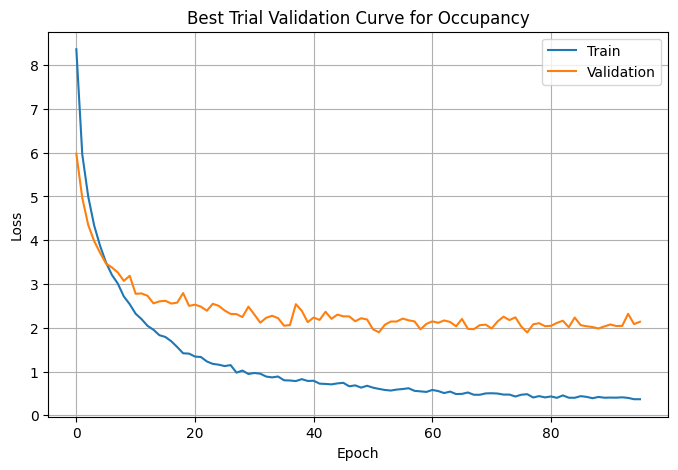

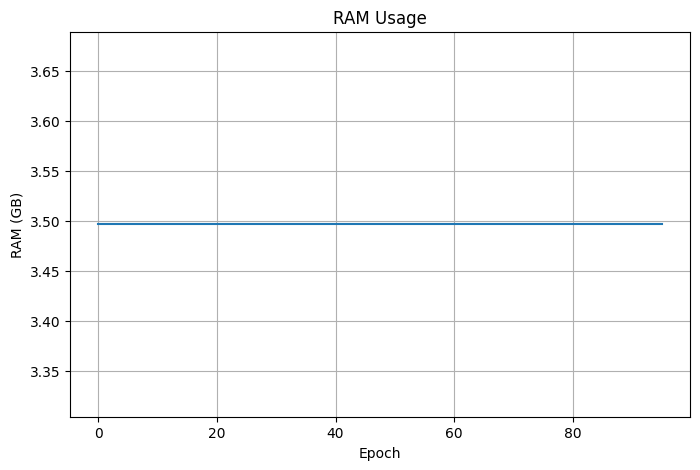

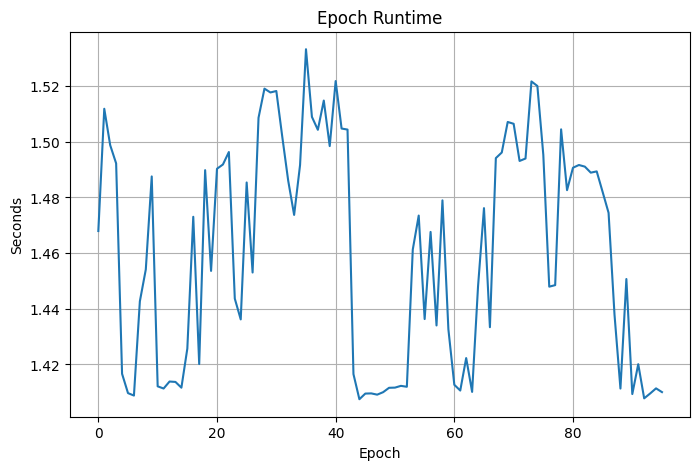

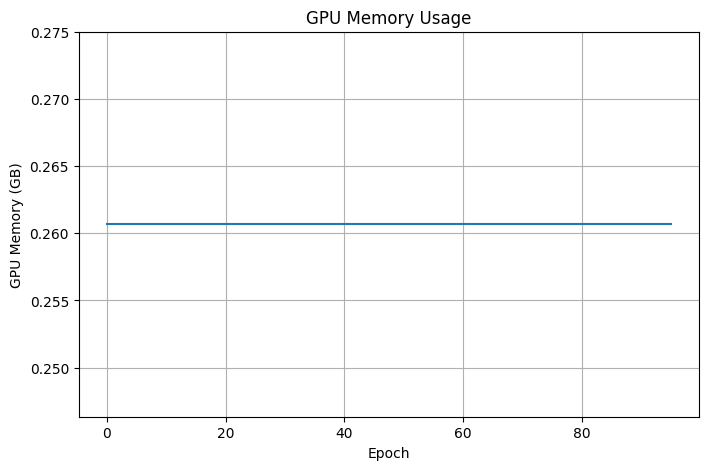

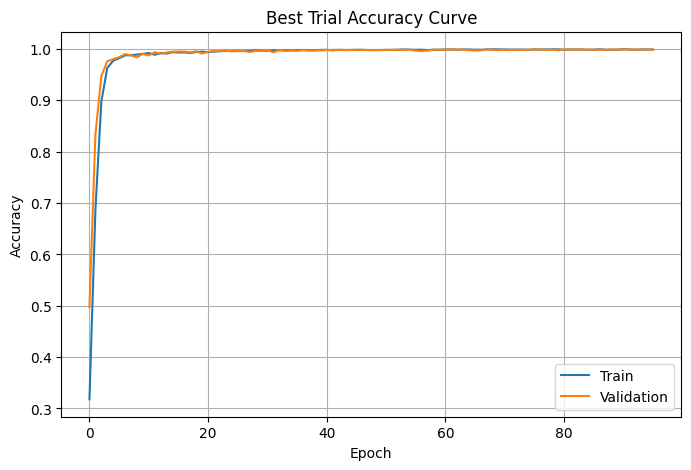

Best Epochs: 96
Best Validation Loss: 1.9044757187366486
Occupancy Loss Function: MSELoss()
Room Loss Function: CrossEntropyLoss()
Epoch 1/30 | Train Loss: 11.4651, Test Loss: 8.3068 | Train Occ Acc: 0.482, Train Room Acc: 0.267, Test Occ Acc: 0.596, Test Room Acc: 0.371
Epoch 2/30 | Train Loss: 8.3542, Test Loss: 6.4462 | Train Occ Acc: 0.553, Train Room Acc: 0.473, Test Occ Acc: 0.507, Test Room Acc: 0.594
Epoch 3/30 | Train Loss: 6.4552, Test Loss: 5.1708 | Train Occ Acc: 0.552, Train Room Acc: 0.698, Test Occ Acc: 0.610, Test Room Acc: 0.792
Epoch 4/30 | Train Loss: 5.2292, Test Loss: 4.1207 | Train Occ Acc: 0.585, Train Room Acc: 0.848, Test Occ Acc: 0.661, Test Room Acc: 0.908
Epoch 5/30 | Train Loss: 4.3450, Test Loss: 3.8667 | Train Occ Acc: 0.583, Train Room Acc: 0.924, Test Occ Acc: 0.641, Test Room Acc: 0.949
Epoch 6/30 | Train Loss: 3.8296, Test Loss: 3.8493 | Train Occ Acc: 0.597, Train Room Acc: 0.955, Test Occ Acc: 0.679, Test Room Acc: 0.961
Epoch 7/30 | Train Loss: 3.4

In [18]:

def objective(trial):
    trial_config = {
        "sequence_length":       60,
        "future":                1,        
        "test_ratio":            0.25,  # keep fixed

        "temporal_batch_size":   64,
        "temporal_epochs":       1,    # shorter per trial, tune fully at the end
        "temporal_hidden_dim":   64,
        "temporal_num_heads":    4,
        "temporal_num_layers":   3,
        "temporal_dropout":      0.1,

        "spatial_batch_size":    64,
        "spatial_epochs":        trial.suggest_int("spatial_epochs",5,100,step=1),
        "spatial_hidden_dim":    32,
        "spatial_num_heads":     2,
        "spatial_num_layers":    1,
        "spatial_dropout":       .1,

        "num_rooms":             5,   
        "lr":                    .001,
        "w1":                    1.0,
        "w2":                    2.0
    }
    trial_sequences = {}
    for i,room in enumerate(file_paths.keys(),start=1):
        data = room_scaled_data[room]
        X_seq, y_seq, t_seq = create_sequences(data['X'], data['y'], data['timestamp'], sequence_length, future)
    # Print shapes to understand the structure
        print(f"{room} - Total sequences created: {X_seq.shape[0]}")
        print(f"{room} - Input sequence shape: {X_seq.shape} (should be [samples, seq_len, features])")
        print(f"{room} - Target shape: {y_seq.shape}")
        print(f"{room} - Timestamp shape: {t_seq.shape}")

    # Split into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=test_ratio, shuffle=True)

    # Print split stats
        print(f"{room} - Training samples: {X_train.shape[0]}")
        print(f"{room} - Testing samples: {X_test.shape[0]}")

    # Store results
        trial_sequences[room] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test
        }
        # === DATALOADERS ===
    train_ds = MultiRoomDataset(trial_sequences, room_list, is_train=True)
    test_ds  = MultiRoomDataset(trial_sequences, room_list, is_train=False)
    train_ld = DataLoader(train_ds, batch_size=trial_config["spatial_batch_size"], shuffle=True)
    test_ld  = DataLoader(test_ds,  batch_size=trial_config["spatial_batch_size"], shuffle=False)

    # === MODEL ===
    model = MultiRoomTransformerModel(
        input_dim=num_sensor_features,
        seq_len=trial_config["sequence_length"],
        temporal_hidden_dim=trial_config["temporal_hidden_dim"],
        temporal_num_heads=trial_config["temporal_num_heads"],
        temporal_num_layers=trial_config["temporal_num_layers"],
        num_rooms=trial_config["num_rooms"],
        spatial_hidden_dim=trial_config["spatial_hidden_dim"],
        spatial_num_heads=trial_config["spatial_num_heads"],
        spatial_num_layers=trial_config["spatial_num_layers"],
        temporal_dropout=trial_config["temporal_dropout"],
        spatial_dropout=trial_config["spatial_dropout"],
    ).to(device)

    optimizer  = torch.optim.Adam(model.parameters(), lr=trial_config["lr"])
    criterion  = nn.MSELoss()
    classif    = nn.CrossEntropyLoss()
    w1, w2     = 1.0, 2.0

    # === TRAINING LOOP ===
    best_test_loss = float('inf')
    train_occ_curve = []
    val_occ_curve = []

    train_room_curve = []
    val_room_curve = []
    epoch_time_curve = []
    ram_curve = []
    gpu_curve = []
    for epoch in range(trial_config["spatial_epochs"]):
        epoch_start = time.time()
        model.train()
        train_occ_loss = 0.0
        n_batches = 0
        train_room_correct = 0.0
        train_room_total = 0.0
        for X_batch, y_batch in train_ld:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            _, sp_occ, sp_room = model(X_batch)
            loss_occ = w1 * criterion(sp_occ, y_batch[..., 0])
            
            
            loss_room = w2*classif(
                sp_room.view(-1,trial_config["num_rooms"]),
                (y_batch[...,1]-1).long().view(-1)
            )
            loss = w1*loss_occ + w2*loss_room
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_occ_loss += loss_occ.item()
            with torch.no_grad():
                preds=sp_room.argmax(dim=-1).view(-1)
                acts = (y_batch[...,1]-1).long().view(-1)
                train_room_correct +=(preds == acts).sum().item()
                train_room_total += acts.numel()
            n_batches +=1
        # === VALIDATION ===
        train_occ_curve.append(train_occ_loss / n_batches)
        train_room_curve.append(train_room_correct / train_room_total)
        
        model.eval()
        
        with torch.no_grad():
            
            occ_preds, occ_acts = [], []
            room_preds, room_acts = [], []
            for X_batch, y_batch in test_ld:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                _, sp_occ, sp_room = model(X_batch)
                occ_preds.append(sp_occ.cpu())
                occ_acts.append(y_batch[..., 0].cpu())

                room_preds.append(sp_room.cpu())
                room_acts.append((y_batch[...,1]-1).long().cpu())

            occ_preds = torch.cat(occ_preds)
            occ_acts  = torch.cat(occ_acts)
            room_preds = torch.cat(room_preds)
            room_acts = torch.cat(room_acts)
           
           
            val_occ_loss = (
                w1 * criterion(occ_preds, occ_acts).item() 
            )
            val_room_loss = w2* classif(room_preds.view(-1,trial_config["num_rooms"]),room_acts.view(-1)).item()
            room_pred_labels = room_preds.argmax(dim=-1).view(-1)
            room_acts_flat = room_acts.view(-1)
            val_room_acc = (room_pred_labels == room_acts_flat).float().mean().item()
        val_occ_curve.append(val_occ_loss)
        val_room_curve.append(val_room_acc)

        # Report and prune bad trials early
        epoch_time = time.time() - epoch_start

        process = psutil.Process(os.getpid())
        ram_gb = process.memory_info().rss / (1024**3)

        if torch.cuda.is_available():
            gpu_gb = torch.cuda.max_memory_allocated() / (1024**3)
        else:
            gpu_gb = 0

        epoch_time_curve.append(epoch_time)
        ram_curve.append(ram_gb)
        gpu_curve.append(gpu_gb)

        torch.cuda.reset_peak_memory_stats()
        trial.report(val_occ_loss+val_room_loss, epoch) #for pruning bad trials early 
        if trial.should_prune():
           raise optuna.exceptions.TrialPruned()

        best_test_loss = min(best_test_loss, val_occ_loss+val_room_loss)
    trial.set_user_attr("val_occ_curve", val_occ_curve)
    trial.set_user_attr("train_occ_curve", train_occ_curve)
    trial.set_user_attr("val_room_curve",val_room_curve)
    trial.set_user_attr("train_room_curve",train_room_curve)
    trial.set_user_attr("epoch_time_curve", epoch_time_curve)
    trial.set_user_attr("ram_curve", ram_curve)
    trial.set_user_attr("gpu_curve", gpu_curve)
    return best_test_loss
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(
    objective,
    n_trials=100,
    timeout=7200
)

best_epochs = study.best_trial.params["spatial_epochs"]

print("Best Epochs:", best_epochs)
print("Best Validation Loss:", study.best_trial.value)

best = study.best_trial

plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["train_occ_curve"], label="Train")
plt.plot(best.user_attrs["val_occ_curve"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best Trial Validation Curve for Occupancy")
plt.legend()
plt.grid()
plt.show()
#RAM
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["ram_curve"])
plt.xlabel("Epoch")
plt.ylabel("RAM (GB)")
plt.title("RAM Usage")
plt.grid(True)
plt.show()
#TIME
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["epoch_time_curve"])
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch Runtime")
plt.grid(True)
plt.show()
#GPU
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["gpu_curve"])
plt.xlabel("Epoch")
plt.ylabel("GPU Memory (GB)")
plt.title("GPU Memory Usage")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["train_room_curve"], label="Train")
plt.plot(best.user_attrs["val_room_curve"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best Trial Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

final_epochs = study.best_trial.params["spatial_epochs"]

print("Best Epochs:", best_epochs)
print("Best Validation Loss:", study.best_trial.value)

best = study.best_trial

final_model=MultiRoomTransformerModel(
        input_dim=num_sensor_features,
        seq_len=config["sequence_length"],
        temporal_hidden_dim=config["temporal_hidden_dim"],
        temporal_num_heads=config["temporal_num_heads"],
        temporal_num_layers=config["temporal_num_layers"],
        num_rooms=config["num_rooms"],
        spatial_hidden_dim=config["spatial_hidden_dim"],
        spatial_num_heads=config["spatial_num_heads"],
        spatial_num_layers=config["spatial_num_layers"],
        temporal_dropout=config["temporal_dropout"],
        spatial_dropout=config["spatial_dropout"],
    ).to(device)


preds_occup_np,preds_room_np, actuals_occup_np,actuals_room_np = train_multiroom_model(
    model=multi_room_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=config["spatial_epochs"],
    lr=0.001
)


In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
plot_start = 0
plot_end = 200

# === TRAIN THE MODEL ===

final_model=MultiRoomTransformerModel(
        input_dim=num_sensor_features,
        seq_len=config["sequence_length"],
        temporal_hidden_dim=config["temporal_hidden_dim"],
        temporal_num_heads=config["temporal_num_heads"],
        temporal_num_layers=config["temporal_num_layers"],
        num_rooms=config["num_rooms"],
        spatial_hidden_dim=config["spatial_hidden_dim"],
        spatial_num_heads=config["spatial_num_heads"],
        spatial_num_layers=config["spatial_num_layers"],
        temporal_dropout=config["temporal_dropout"],
        spatial_dropout=config["spatial_dropout"],
    ).to(device)


preds_occup_np,preds_room_np, actuals_occup_np,actuals_room_np = train_multiroom_model(
    model=multi_room_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=final_epochs,
    lr=0.001
)

print("\n Final Evaluation Metrics Per Room (Spatial Model):")
with open(summary_txt, "a") as f:
    f.write("\n SPATIAL (Multi-Room) Transformer Evaluation \n")

    # Store all spatial results
    spatial_results = []
    #gets the predictedd room for all samples at once
    y_room_pred_all = np.argmax(preds_room_np,axis=-1).flatten()+1 #shape: (samples, num_rooms)
    y_room_true_all = (actuals_room_np).astype(int).flatten() # plus two to fix error with cm matrix not showing all collumns
    #print("Debug: pred ",y_room_pred_all)
    #print("Debug: true ",y_room_true_all)
    all_room_labels= list(range(1,config["num_rooms"]+1))
    cm = confusion_matrix(
        y_room_true_all,
        y_room_pred_all,
        labels=all_room_labels
    )
    print(cm)
    print(
        classification_report(
            y_room_true_all,
            y_room_pred_all,
            labels=all_room_labels,
            target_names=[str(x) for x in all_room_labels],
            zero_division = 0)
    )
  #  cm.print_stats()
    #Subplots for occupancy
    num_rooms=config["num_rooms"]
    fig, axes = plt.subplots(num_rooms, 1, figsize=(12,3*num_rooms),sharex=True)
    
            # Iterate through each room to calculate both occupancy and room number metrics
    for room_index in range(config["num_rooms"]):
            room_id_display = room_index + 1 # For printing and appending

            # Occupancy Metrics
            y_occup_true = actuals_occup_np[:, room_index]
            y_occup_pred = preds_occup_np[:, room_index]
            rmse_O = np.sqrt(mean_squared_error(y_occup_true, y_occup_pred))
            mae_O = mean_absolute_error(y_occup_true, y_occup_pred)
            r2_O = r2_score(y_occup_true, y_occup_pred)

            # Room Number Metrics
            # Convert numpy array to torch tensor before passing to torch.argmax


            #rmse_R = np.sqrt(mean_squared_error(y_room_true, y_room_pred_numpy))
            #mae_R = mean_absolute_error(y_room_true, y_room_pred_numpy)
            #r2_R = r2_score(y_room_true, y_room_pred_numpy)

            print(f"\nRoom {room_id_display}:")
            print(f"  RMSE_O: {rmse_O:.3f}")
            print(f"  MAE_O : {mae_O:.3f}")
            print(f"  R²_O  : {r2_O:.3f}")



        # Append all metrics for the current room as a single tuple
            spatial_results.append((room_id_display, rmse_O, mae_O, r2_O))

        #Slice the data for the plot
            true_slice = y_occup_true[plot_start:plot_end]
            pred_slice = y_occup_pred[plot_start:plot_end]
            x_axis = range(plot_start,plot_start+len(true_slice))

        #Generate Subplot for current room
            ax = axes[room_index]
            ax.plot(x_axis,true_slice,label="Actual", color="orange",linewidth=1.5)
            ax.plot(x_axis,pred_slice,label="Predicted", color="blue",linestyle="--",alpha=0.8)
            ax.set_title(f"Room({room_id_display}) Occupancy(from {plot_start} to {plot_end})")
            ax.set_ylabel("Occupants")
            ax.grid(True,linestyle=":",alpha=0.6)
            if room_index == 0:
                ax.legend(loc="upper right")

    axes[-1].set_xlabel("Sample index")
    plt.tight_layout()

    plt.show()
    f.write(f"Confusion Matrix: {cm}\n")
    # Write in temporal-style format
    # The loop will now correctly unpack 7 values from each tuple in spatial_results
    for room_id_from_tuple, rmse_O, mae_O, r2_O in spatial_results:
        f.write(f"R{room_id_from_tuple}\tRMSE_O: {rmse_O:.4f}\tRMSE_R: \tMAE_O: {mae_O:.4f}\tMAE_R: \tR²_O: {r2_O:.4f}\n")
'''
print("\n Final Evaluation Metrics Per Room (Spatial Model):")
with open(summary_txt, "a") as f:
    f.write("\n SPATIAL (Multi-Room) Transformer Evaluation \n")

    # Store all spatial results
    spatial_results = []
    #gets the predictedd room for all samples at once
    y_room_pred_all = np.argmax(preds_room_np, axis=-1)+1 #shape: (samples, num_rooms)
    # Iterate through each room to calculate both occupancy and room number metrics
    for room_index in range(config["num_rooms"]):
        room_id_display = room_index + 1 # For printing and appending

        # Occupancy Metrics
        y_occup_true = actuals_occup_np[:, room_index]
        y_occup_pred = preds_occup_np[:, room_index]
        rmse_O = np.sqrt(mean_squared_error(y_occup_true, y_occup_pred))
        mae_O = mean_absolute_error(y_occup_true, y_occup_pred)
        r2_O = r2_score(y_occup_true, y_occup_pred)

        # Room Number Metrics
        # Convert numpy array to torch tensor before passing to torch.argmax
        y_room_true = (actuals_room_np[:,room_index]).astype(int)

        y_room_pred_numpy = y_room_pred_all[:,room_index] # Convert back to numpy for sklearn metrics
        all_room_labels = list(range(1,config["num_rooms"]+1))

        cm = pd.crosstab(
                pd.Series(y_room_true, name='Actual'),
                pd.Series(y_room_pred_numpy, name ='Predicted'),
                rownames=['Actual'],
                colnames=['Predicted'],
                dropna=False

        )
        cm = cm.reindex(
                index=all_room_labels,
                columns=all_room_labels,
                fill_value=0
        )
        #rmse_R = np.sqrt(mean_squared_error(y_room_true, y_room_pred_numpy))
        #mae_R = mean_absolute_error(y_room_true, y_room_pred_numpy)
        #r2_R = r2_score(y_room_true, y_room_pred_numpy)

        print(f"\nRoom {room_id_display}:")
        print(f"  RMSE_O: {rmse_O:.3f}")
        print(f"  MAE_O : {mae_O:.3f}")
        print(f"  R²_O  : {r2_O:.3f}")

        print(f"\nRoom {room_index +1} Confusion Matrix:")
        print(cm)

        # Append all metrics for the current room as a single tuple
        spatial_results.append((room_id_display, rmse_O, mae_O, r2_O,cm))

    # Write in temporal-style format
    # The loop will now correctly unpack 7 values from each tuple in spatial_results
    for room_id_from_tuple, rmse_O, mae_O, r2_O, cm in spatial_results:
        f.write(f"R{room_id_from_tuple}\tRMSE_O: {rmse_O:.4f}\tRMSE_R: \tMAE_O: {mae_O:.4f}\tMAE_R: \tR²_O: {r2_O:.4f}\tCM: {cm}\n")
'''

Occupancy Loss Function: MSELoss()
Room Loss Function: CrossEntropyLoss()
Epoch 1/96 | Train Loss: 0.9825, Test Loss: 2.6863 | Train Occ Acc: 0.698, Train Room Acc: 0.994, Test Occ Acc: 0.704, Test Room Acc: 0.993
Epoch 2/96 | Train Loss: 0.8964, Test Loss: 2.4821 | Train Occ Acc: 0.709, Train Room Acc: 0.995, Test Occ Acc: 0.711, Test Room Acc: 0.996
Epoch 3/96 | Train Loss: 0.8614, Test Loss: 2.6972 | Train Occ Acc: 0.712, Train Room Acc: 0.996, Test Occ Acc: 0.705, Test Room Acc: 0.995
Epoch 4/96 | Train Loss: 0.8890, Test Loss: 2.7128 | Train Occ Acc: 0.714, Train Room Acc: 0.995, Test Occ Acc: 0.713, Test Room Acc: 0.995
Epoch 5/96 | Train Loss: 0.8480, Test Loss: 2.5890 | Train Occ Acc: 0.710, Train Room Acc: 0.996, Test Occ Acc: 0.702, Test Room Acc: 0.995
Epoch 6/96 | Train Loss: 0.8208, Test Loss: 2.7022 | Train Occ Acc: 0.714, Train Room Acc: 0.996, Test Occ Acc: 0.719, Test Room Acc: 0.994
Epoch 7/96 | Train Loss: 0.7759, Test Loss: 2.4186 | Train Occ Acc: 0.725, Train Room 

In [ ]:


def plot_multiroom_loss_subplots(train_losses_per_room, test_losses_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Train/Test Loss per Room", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(train_losses_per_room[room], label='Train Loss')
        axs[i].plot(test_losses_per_room[room], label='Test Loss')
        axs[i].set_title(room)
        axs[i].set_xlabel("Epoch")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Loss")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


def plot_multiroom_accuracy_subplots(train_accs_per_room, test_accs_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Train/Test Accuracy per Room", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(train_accs_per_room[room], label='Train Acc')
        axs[i].plot(test_accs_per_room[room], label='Test Acc')
        axs[i].set_title(room)
        axs[i].set_xlabel("Epoch")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Accuracy")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


def plot_multiroom_actual_vs_predicted_subplots(preds_per_room, actuals_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Actual vs Predicted (First 100 Samples)", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(actuals_per_room[room], label='Actual')
        axs[i].plot(preds_per_room[room], label='Predicted')
        axs[i].set_title(room)
        axs[i].set_xlabel("Index")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Occupancy")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


# === CALL GROUPED PLOTS ===
plot_multiroom_loss_subplots(
    spatial_train_losses_per_room,
    spatial_test_losses_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_loss_all_rooms.png")
)

plot_multiroom_accuracy_subplots(
    spatial_train_accs_per_room,
    spatial_test_accs_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_accuracy_all_rooms.png")
)

In [ ]:


# Populate spatial_preds_per_room and spatial_actuals_per_room
# These were populated within train_multiroom_model but were not correctly assigned to the top-level variables expected by the plot function.
spatial_preds_per_room = spatial_occupancy_preds_per_room
spatial_actuals_per_room = spatial_occupancy_actuals_per_room

In [ ]:


plot_multiroom_actual_vs_predicted_subplots(
    spatial_preds_per_room,
    spatial_actuals_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_actual_vs_predicted_all_rooms.png")
)

In [ ]:


# === GET ONE BATCH FROM TEST LOADER ===
multiroom_batch = next(iter(test_loader))  # or use train_loader
X_batch = multiroom_batch[0].to(device)    # shape: (batch_size, num_rooms, seq_len, input_dim)

In [ ]:


# === Confirm input shape ===
print("X_batch shape:", X_batch.shape)  # Should be (batch, num_rooms, seq_len, input_dim)

In [ ]:


# === PLOT ROOM DEPENDENCY HEATMAP === change for room dependency bookmark7
def plot_room_dependency_heatmap(model, input_batch, room_names=None, save=True, show=False):
    model.eval()
    with torch.no_grad():
        assert input_batch.ndim == 4, f"Expected shape (batch, rooms, seq_len, features), got {input_batch.shape}"
        batch_size, num_rooms, seq_len, input_dim = input_batch.shape

        # Encode each room using its temporal encoder
        room_contexts = []
        for r in range(num_rooms):
            x_room = input_batch[:, r]  # (batch, seq_len, input_dim)
            encoded = model.room_encoders[r](x_room)  # (batch, seq_len, hidden_dim)
            pooled = encoded.mean(dim=1)  # (batch, hidden_dim)
            room_contexts.append(pooled)

        room_contexts = [model.temporal_to_spatial(c) for c in room_contexts]

        # Stack into (batch, num_rooms, hidden_dim)
        context_tensor = torch.stack(room_contexts, dim=1)

        # Apply spatial encoder to get fused representation
        fused = model.spatial_encoder(context_tensor)  # (batch, num_rooms, hidden_dim)

        # Average across the batch → (num_rooms, hidden_dim)
        avg_representation = fused.mean(dim=0).cpu().numpy()

        # Compute correlation matrix → (num_rooms, num_rooms)
        corr_matrix = np.corrcoef(avg_representation)

        # Plot heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                    xticklabels=room_names, yticklabels=room_names)
        plt.title("Room Dependency Heatmap (Learned Spatial Representations)")
        plt.xlabel("Rooms")
        plt.ylabel("Rooms")

        if save:
            plt.savefig(os.path.join(RESULTS_DIR, "multiroom_room_dependency_heatmap.png"))
        if show:
            plt.show()
        else:
            plt.close()

In [ ]:


# === CALL FUNCTION ===
plot_room_dependency_heatmap(multi_room_model, X_batch, room_names)

In [ ]:


# === SAVE RUNTIME INFO ===
end_time = time.time()
elapsed_time = end_time - start_time
elapsed_minutes = elapsed_time / 60

with open(summary_txt, "a") as f:
    f.write(f"\nTotal Runtime: {elapsed_time:.2f} seconds ({elapsed_minutes:.2f} minutes)\n")